# Phase transitions

## Test: distance to true sequences as function of temperature

### Imports


In [2]:
import numpy as np
import os
from tqdm import tqdm

from plm_hamming_dist import hamming_dist, hamming_dist_oneseq_to_batch_new
from plm_seq_utils import letters_to_nums, sequences_from_fasta, one_hot_seq_batch
from plm_PCA_func import plot_projected_pca, plot_pca_of_sequences, kl_divergence_between_pca_distributions, return_pca_results, average_minimum_distance, symmetric_average_minimum_distance


In [3]:
def distance(gen_seqs, ref_seqs):
    """
    Calculate the mean Hamming distance from each generated sequence to a batch of reference sequences.

    Args:
        gen_seqs (list of str): List of generated sequences.
        ref_seqs (list of str): List of reference sequences.

    Returns:
        float: Mean of average Hamming distances between each generated sequence and all reference sequences.
    """
    distances = []
    for seq in gen_seqs:
        # hamming_dist_oneseq_to_batch should return a list of distances between seq and each ref_seq
        dists = hamming_dist_oneseq_to_batch_new(seq, ref_seqs)
        avg_dist = np.mean(dists)
        distances.append(avg_dist)

    return np.mean(distances)

## Import generated sequences and train sequences as reference

In [4]:
# -------------- Load train sequences ----------------
# Load train sequences
family = 'jdoms_bacteria_train2'
cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
filename = cwd + f'/CODE/DataAttentionDCA/jdoms/{family}.fasta'

#filename = cwd + f'\CODE\DataAttentionDCA\jdoms\{family}.fasta'

train_sequences = sequences_from_fasta(filename)
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]

# -------------- Load generated sequences ----------------
cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
#cwd='C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main'
save_dir = "generated_sequences"

betas = [0.01, 0.1, 0.5, 1, 2, 4, 8]
distances = []

for b in tqdm(betas):
    filename = f'gen_seqs_w_init_seq_Ns30000_r0.1_b{b}'
    output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir}/{filename}.npy'
    gen_sequences = np.load(output_file)
    distances.append(distance(gen_sequences[::63], train_sequences_num[::63]))
distances = np.array(distances)

100%|██████████| 7/7 [00:03<00:00,  1.93it/s]


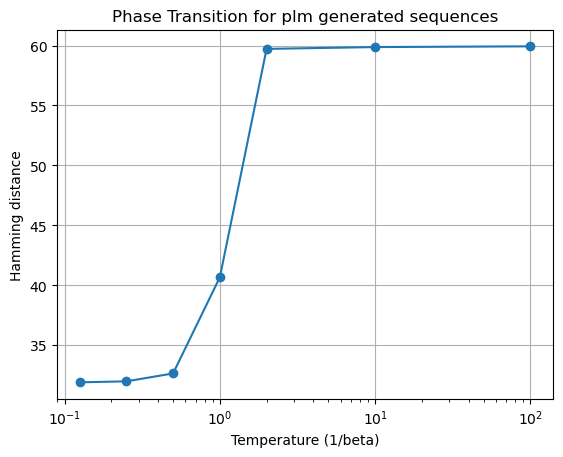

In [5]:
# -------------- Plot phase transition ----------------
import matplotlib.pyplot as plt

# plot distances vs temperature 1/beta
temps = [1/b for b in betas]
plt.plot(temps, distances, marker='o')
plt.xscale('log')
plt.xlabel('Temperature (1/beta)')
#plt.xlabel('Beta')
plt.ylabel('Hamming distance')
plt.title('Phase Transition for plm generated sequences')
plt.grid()
#plt.savefig(cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir}/phase_transition.png')
plt.show()

In [6]:
# Check hamming distance of a random sequence to reference sequences
# Generate 100 random sequences of ints between 0 and 21 and lenfth 63
random_sequences = np.random.randint(0, 22, size=(100, 63))
rand_dist = distance(random_sequences, train_sequences_num)
print(f"Mean Hamming distance of random sequences to reference sequences: {rand_dist}")


Mean Hamming distance of random sequences to reference sequences: 60.25882223141635


In [7]:
## -------------- Load train sequences ----------------
## Load train sequences
#family = 'jdoms_bacteria_train2'
#cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
#filename = cwd + f'/CODE/DataAttentionDCA/jdoms/{family}.fasta'
#
##filename = cwd + f'\CODE\DataAttentionDCA\jdoms\{family}.fasta'
#
#train_sequences = sequences_from_fasta(filename)
#train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
#
## -------------- Load generated sequences ----------------
#cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
##cwd='C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main'
#save_dir = "generated_sequences"

betas = [0.01, 0.1, 0.5, 1, 2, 4, 8]
distances2 = []

for b in tqdm(betas):
    filename = f'gen_seqs_w_init_seq_Ns30000_r0.1_b{b}'
    output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir}/{filename}.npy'
    gen_sequences = np.load(output_file)
    pca_results, pca_results_data_test = return_pca_results(gen_sequences, train_sequences_num)
    dist,_ = kl_divergence_between_pca_distributions(pca_results, pca_results_data_test, bins=100)

    distances2.append(dist)
distances2 = np.array(distances2)

 14%|█▍        | 1/7 [00:05<00:30,  5.11s/it]

Max diff:  0.007333333333085328


 29%|██▊       | 2/7 [00:09<00:24,  4.92s/it]

Max diff:  0.007633333333075328


 43%|████▎     | 3/7 [00:14<00:19,  4.86s/it]

...

Max diff:  0.07966565990635581


 86%|████████▌ | 6/7 [00:29<00:04,  4.81s/it]

Max diff:  0.29045750929938513


100%|██████████| 7/7 [00:34<00:00,  4.93s/it]

Max diff:  0.5662908426235241


[20.77794927 20.68601487 20.38090052  3.97690075  4.99797102  7.62505195
  8.12874991]


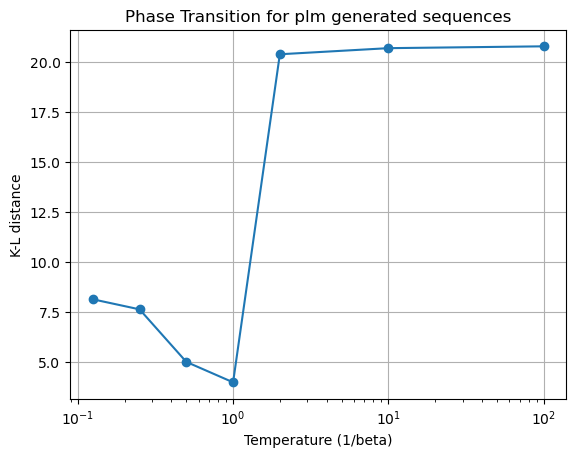

In [8]:
# -------------- Plot phase transition ----------------
print(distances2)
# plot distances vs temperature 1/beta
temps = [1/b for b in betas]
plt.plot(temps, distances2, marker='o')
plt.xscale('log')
plt.xlabel('Temperature (1/beta)')
#plt.xlabel('Beta')
plt.ylabel('K-L distance')
plt.title('Phase Transition for plm generated sequences')
plt.grid()
#plt.savefig(cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir}/phase_transition.png')
plt.show()

In [9]:
pca_results, pca_results_data_test = return_pca_results(train_sequences_num[::10], train_sequences_num[::10])
dist,_ = kl_divergence_between_pca_distributions(pca_results, pca_results_data_test, bins=100)
print(dist)

Max diff:  0.0006891798754726534
0.031737906151234334


In [13]:
distances3 = []

for b in tqdm(betas):
    filename = f'gen_seqs_w_init_seq_Ns30000_r0.1_b{b}'
    output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir}/{filename}.npy'
    gen_sequences = np.load(output_file)
    dist = symmetric_average_minimum_distance(gen_sequences[::1], train_sequences_num[::1])
    distances3.append(dist)
distances3 = np.array(distances3)

100%|██████████| 7/7 [11:38<00:00, 99.78s/it] 


[53.44713936 54.64988052 54.12890567 38.14357814 30.82315465 30.9653355
 31.84480936]


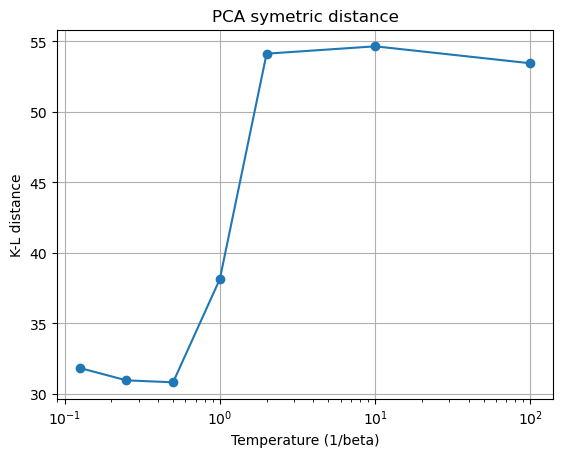

In [12]:
# -------------- Plot phase transition ----------------
print(distances3)
# plot distances vs temperature 1/beta
temps = [1/b for b in betas]
plt.plot(temps, distances3, marker='o')
plt.xscale('log')
plt.xlabel('Temperature (1/beta)')
#plt.xlabel('Beta')
plt.ylabel('K-L distance')
plt.title('PCA symetric distance')
plt.grid()
#plt.savefig(cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir}/phase_transition.png')
plt.show()